# Regional Patterns of U.S. Severe Weather Power Outages



## 1. Overview

Exploratory data analysis of severe weather–related power outages across the United States in 2023.

### Question

- Which states experience the highest frequency of severe weather outages?

- Which states experience the most servere outages?

- How is outage impact distributed within high-impact states?



### 1.0 Setup and Data Loading

In [48]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

In [49]:
outages_raw = pd.read_csv("eaglei_outages_with_events_2023.csv")

print("Shape:", outages_raw.shape)
display(outages_raw.head().T)

Shape: (77341, 14)


,0,1,2,3,4
event_id,Alabama-0,Alabama-0,Alabama-0,Alabama-0,Alabama-0
state_event,Alabama,Alabama,Alabama,Alabama,Alabama
Datetime Event Began,2023-01-12 14:00:00,2023-01-12 14:00:00,2023-01-12 14:00:00,2023-01-12 14:00:00,2023-01-12 14:00:00
Datetime Restoration,2023-01-13 03:00:00,2023-01-13 03:00:00,2023-01-13 03:00:00,2023-01-13 03:00:00,2023-01-13 03:00:00
Event Type,Severe Weather,Severe Weather,Severe Weather,Severe Weather,Severe Weather
fips,1001,1003,1003,1007,1009
state,Alabama,Alabama,Alabama,Alabama,Alabama
county,Autauga,Baldwin,Baldwin,Bibb,Blount
start_time,2023-01-12 19:00:00,2023-01-12 15:45:00,2023-01-12 19:15:00,2023-01-13 04:00:00,2023-01-12 16:30:00
duration,52.0,1.25,3.0,7.25,3.5


## 2. Data Preparation

### 2.1 Clean Column Names

In [50]:
outages_clean = outages_raw.copy()

outages_clean.columns = (
    outages_clean.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

### 2.2 Datetime Conversion

In [51]:
date_columns = ['datetime_event_began', 'datetime_restoration', 'start_time', 'end_time']

for col in date_columns:
    outages_clean[col] = pd.to_datetime(outages_clean[col], errors='coerce')

### 2.3 Clean Event Type (Multi-label Handling)

In [52]:
def clean_and_split(x):
    if pd.isna(x):
        return []

    x = x.lower().replace("\xa0", " ")
    parts = re.split(r"\s*-\s*", x)
    parts = [p.strip() for p in parts if p.strip() != ""]

    return parts

outages_clean["event_list"] = outages_clean["event_type"].apply(clean_and_split)

## 3. Scope Definition

### 3.1 Event Distribution

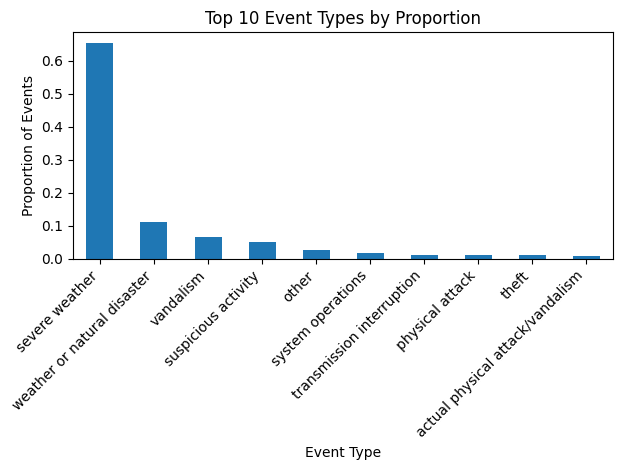

In [53]:
event_counts = (
    outages_clean["event_list"]
    .explode()
    .value_counts(normalize=True)
    .head(10)
)

event_counts.plot(kind="bar")
plt.title("Top 10 Event Types by Proportion")
plt.ylabel("Proportion of Events")
plt.xlabel("Event Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Focus on severe weather events

Severe weather represents the majority of outage events in the dataset (over 60% of all observations).

To improve comparability across observations and reduce heterogeneity introduced by different event types, the following analyses focus on outage events associated with severe weather and weather or natural disaster.

In [54]:
event_type_weather = outages_clean[
    outages_clean["event_list"].apply(lambda x: "severe weather" in x or "weather or natural disaster" in x)
]

print(f"Severe weather and natural disaster events: {len(event_type_weather):,} rows")

Severe weather and natural disaster events: 61,341 rows


## 4. State-Level Analysis

In [55]:
state_summary = (
    event_type_weather
    .groupby("state")["mean_customers"]
    .agg(
        avg_customers="mean",
        n_events="count"
    )
    .query("n_events >= 10")
)

### 4.1 Outage Frequency by State

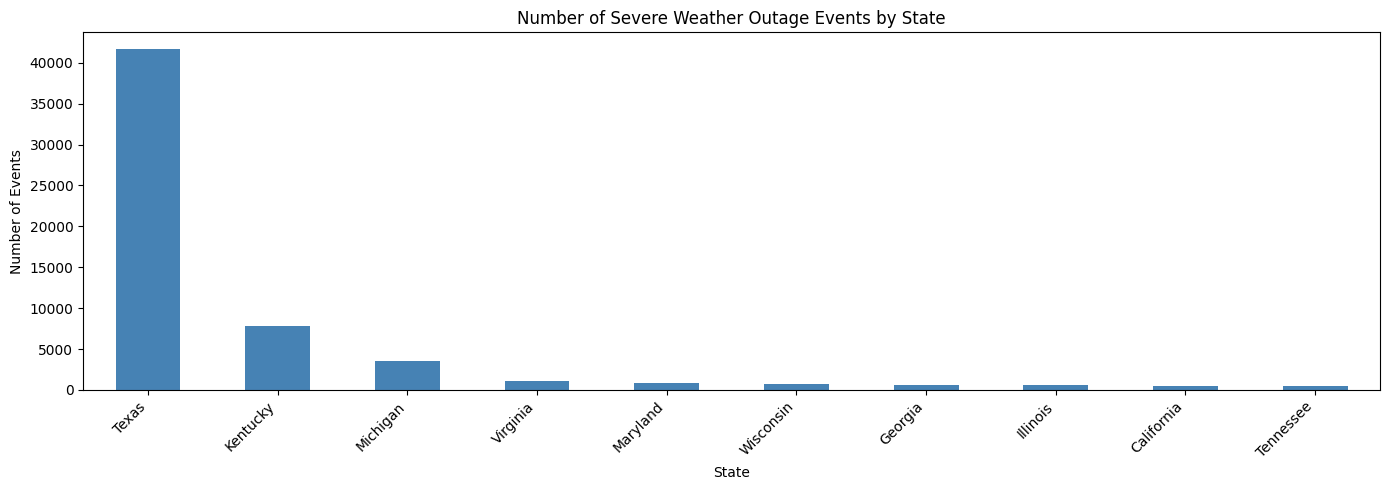

            avg_customers  n_events
state                              
Texas          838.402855     41629
Kentucky       863.118349      7873
Michigan      2226.992957      3493
Virginia       748.310023      1139
Maryland      2121.044577       906
Wisconsin     1431.996072       719
Georgia        882.965505       660
Illinois       850.948871       610
California    2258.798662       491
Tennessee      989.029540       441


In [56]:
state_frequency = (
    state_summary
    .sort_values("n_events", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(14,5))

state_frequency["n_events"].plot(
    kind="bar",
    color="steelblue",
    ax=ax
)

ax.set_title("Number of Severe Weather Outage Events by State")
ax.set_ylabel("Number of Events")
ax.set_xlabel("State")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(state_frequency.head(10))

Texas experienced the highest number of severe weather outage events.

### 4.2 Average Outage Severity by State

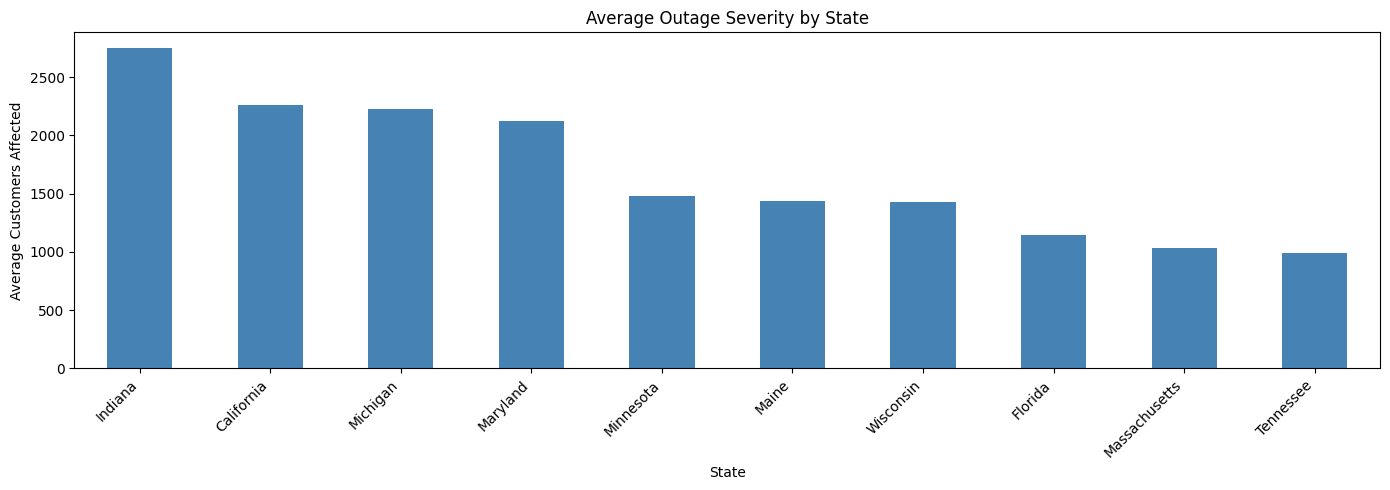

               avg_customers  n_events
state                                 
Indiana          2747.792423        99
California       2258.798662       491
Michigan         2226.992957      3493
Maryland         2121.044577       906
Minnesota        1480.584336       120
Maine            1434.587078       211
Wisconsin        1431.996072       719
Florida          1147.237771       381
Massachusetts    1038.099843       183
Tennessee         989.029540       441


In [57]:
state_severity = (
    state_summary
    .sort_values("avg_customers", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(14,5))

state_severity["avg_customers"].plot(
    kind="bar",
    color="steelblue",
    ax=ax
)

ax.set_title("Average Outage Severity by State")
ax.set_ylabel("Average Customers Affected")
ax.set_xlabel("State")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(state_severity.head(10))

Indiana records the highest average outage severity.

### 4.3 Frequency vs. Severity by State

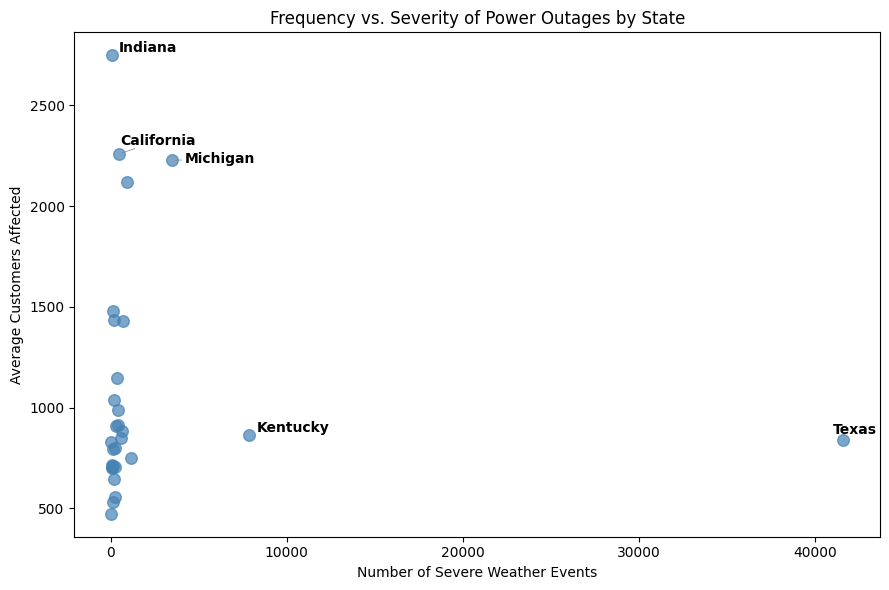

In [59]:
import os

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(state_summary["n_events"], state_summary["avg_customers"],
           s=70, alpha=0.7, color="steelblue")

highlight_states = set(state_summary.nlargest(3, "n_events").index) | \
                    set(state_summary.nlargest(3, "avg_customers").index)

texts = [
    ax.text(state_summary.loc[s, "n_events"], state_summary.loc[s, "avg_customers"],
            s, fontsize=10, fontweight="bold")
    for s in highlight_states
]
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_xlabel("Number of Severe Weather Events")
ax.set_ylabel("Average Customers Affected")
ax.set_title("Frequency vs. Severity of Power Outages by State")

plt.tight_layout()
plt.savefig("figures/frequency_vs_severity.png", dpi=300, bbox_inches="tight")
plt.show()

States with more outage events do not necessarily experienced more severe outages.

- Texas: Frequent but less severe
- Indiana: Infrequent but highly severe
- Michigan: Moderate frequency but highly severe

## 5. County-Level Analysis


### 5.1 County Comparison

County-level analysis focuses on impact concentration — the share of total outage severity contributed by each county — for five states representing distinct frequency-severity profiles identified in Section 4.3 (Texas, Indiana, Michigan, California, Kentucky).

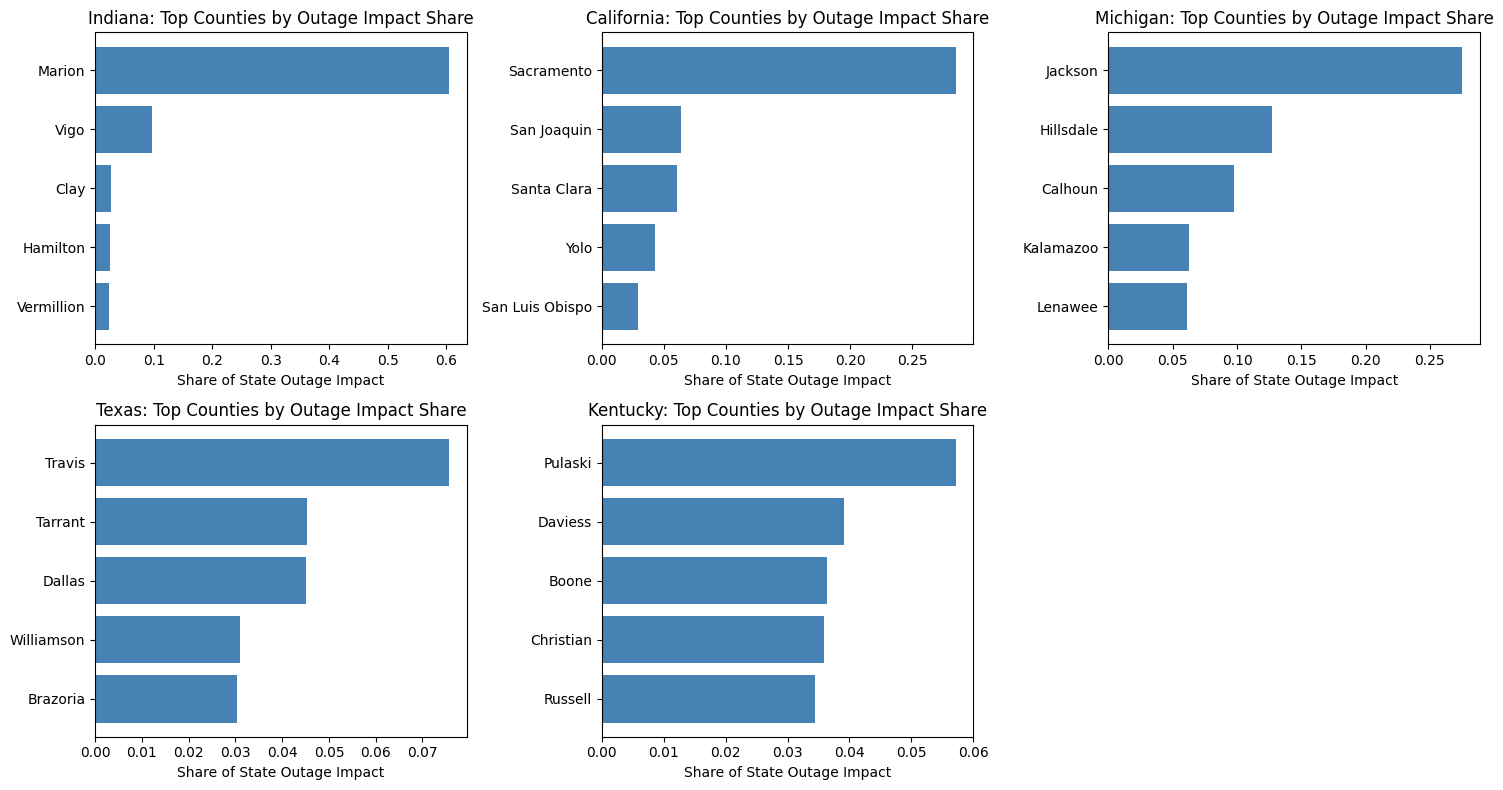

In [60]:
focus_states = ["Indiana", "California", "Michigan", "Texas", "Kentucky"]

county_summary = (
    event_type_weather[event_type_weather["state"].isin(focus_states)]
    .groupby(["state", "county"])
    .agg(avg_customers=("mean_customers", "mean"),
         total_impact=("mean_customers", "sum"),
         n_events=("event_id", "count"))
    .reset_index()
)

county_summary["impact_share"] = (
    county_summary["total_impact"] / county_summary.groupby("state")["total_impact"].transform("sum")
)

top_counties = (
    county_summary.sort_values("impact_share", ascending=False)
    .groupby("state").head(5)
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, state in zip(axes, focus_states):
    data = top_counties[top_counties["state"] == state]
    ax.barh(data["county"], data["impact_share"], color="steelblue")
    ax.set_title(f"{state}: Top Counties by Outage Impact Share")
    ax.set_xlabel("Share of State Outage Impact")
    ax.invert_yaxis()

for ax in axes[len(focus_states):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("figures/county_impact_share.png", dpi=300, bbox_inches="tight")
plt.show()

Outage impact concentration varies significantly by state, ranging from extreme dominance by a single county to relatively even distribution.

- Indiana: Marion County alone accounts for ~60% of state impact.
- California: Sacramento leads at ~ 27%, more than double the second-place county.
- Michigan: Weak concentration — Jackson leads at ~ 27%, but closely trailed by Hillsdale (~22%).
- Texas: Even distribution — top 5 counties all fall within a narrow 3–7% range.
- Kentucky: Even distribution — top 5 counties all fall within a narrow 3–6% range

## 6. Conclusion

### 6.1 Key Insights

- **Outage severity does not scale with event frequency.**

States cluster into distinct frequency-severity profiles rather than falling on a single trend line — meaning the number of outage events alone does not predict how severe those outages will be. This suggests that other unmeasured factors are likely influencing severity, which this analysis is not equipped to identify without additional data.

- **Outage impacts are concentrated differently across counties within each state.**

While some states (e.g., Indiana) exhibit extreme county-level concentration, others (e.g., Texas, Kentucky) show distributed impact patterns, suggesting that outage mitigation strategies may need to differ between states with concentrated risk and those with more geographically distributed impacts.

### 6.2 Limitations

- The analysis is descriptive and does not establish causality between weather conditions and outage severity.

- Outage severity is measured using customer impact only, which does not capture duration or economic losses.